# Chapter 10 — Building Input-Target Examples From Token Sequences

Chapters 7–9 compared ways to turn text into tokens and token IDs.

This chapter turns one token-ID sequence into examples for next-token prediction.

By the end of the chapter, you will be able to:

- define a context, target, context length, and sliding window;
- build fixed-context examples without off-by-one errors;
- decode examples to verify their alignment;
- explain how context length changes the number of examples; and
- distinguish one-target examples from shifted-sequence examples.

The chapter prepares data but does not train a model.

## The Training Relationship

A **context** is the sequence of previous tokens supplied as input.

A **target** is the token immediately after that context in the original sequence.

The **context length** is the number of input tokens in each fixed-context example.

For the character sequence `hello` and a context length of 3, the examples are:

```text
input "hel" -> target "l"
input "ell" -> target "o"
```

The target is adjacent to the input but is not included inside it.

## Start with a Tiny Sequence

The short string `hello` makes every position and slice inspectable.

We will reuse the character-tokenizer ideas from Chapter 7 without introducing a new tokenizer abstraction.

In [1]:
def build_character_mappings(
    text: str,
) -> tuple[dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return character_to_id, id_to_character


def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    return [character_to_id[character] for character in text]


def decode_character_ids(
    character_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    return "".join(id_to_character[character_id] for character_id in character_ids)

In [2]:
tiny_text = "hello"
tiny_character_to_id, tiny_id_to_character = build_character_mappings(tiny_text)
tiny_token_ids = encode_characters(tiny_text, tiny_character_to_id)

assert decode_character_ids(tiny_token_ids, tiny_id_to_character) == tiny_text

print("Text:", tiny_text)
print("Character to ID:", tiny_character_to_id)
print("Token IDs:", tiny_token_ids)

Text: hello
Character to ID: {'e': 0, 'h': 1, 'l': 2, 'o': 3}
Token IDs: [1, 0, 2, 2, 3]


The numerical values are arbitrary labels.

Their order matters because the input and target relationship comes from positions in the sequence.

## Build Two Examples by Hand

A Python slice excludes its end position.

With context length 3, `tiny_token_ids[0:3]` contains positions 0, 1, and 2, so position 3 is the first target.

In [3]:
context_length = 3

for start_position in [0, 1]:
    end_position = start_position + context_length
    input_token_ids = tiny_token_ids[start_position:end_position]
    target_token_id = tiny_token_ids[end_position]

    input_text = decode_character_ids(input_token_ids, tiny_id_to_character)
    target_text = decode_character_ids([target_token_id], tiny_id_to_character)

    print(f"start={start_position}: input={input_text!r}, target={target_text!r}")

start=0: input='hel', target='l'
start=1: input='ell', target='o'


The window moves one position at a time.

This movement is a **stride of 1**, which is the stride used throughout this chapter.

## Generalize the Sliding Window

The example builder returns one input list and one target ID for every valid start position.

Its validation rules describe this helper's contract rather than every possible language-modeling setup.

In particular, unconditional models can exist, but this helper deliberately requires at least one context token.

In [4]:
def build_next_token_examples(
    token_ids: list[int],
    context_length: int,
) -> tuple[list[list[int]], list[int]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1 for this helper.")

    if context_length >= len(token_ids):
        raise ValueError("context_length must leave at least one token for the target.")

    input_examples = []
    target_examples = []

    for start_position in range(len(token_ids) - context_length):
        end_position = start_position + context_length
        input_examples.append(token_ids[start_position:end_position])
        target_examples.append(token_ids[end_position])

    return input_examples, target_examples

In [5]:
tiny_input_examples, tiny_target_examples = build_next_token_examples(
    tiny_token_ids,
    context_length=3,
)

print("Input IDs:", tiny_input_examples)
print("Target IDs:", tiny_target_examples)

Input IDs: [[1, 0, 2], [0, 2, 2]]
Target IDs: [2, 3]


## Decode Every Example

Raw IDs can look plausible even when their alignment is wrong.

Decoding inputs and targets together is the fastest way to inspect the shift.

In [6]:
def print_decoded_examples(
    input_examples: list[list[int]],
    target_examples: list[int],
    id_to_character: dict[int, str],
    max_examples: int | None = None,
) -> None:
    number_to_print = len(input_examples)
    if max_examples is not None:
        number_to_print = min(number_to_print, max_examples)

    for example_number in range(number_to_print):
        input_text = decode_character_ids(
            input_examples[example_number],
            id_to_character,
        )
        target_text = decode_character_ids(
            [target_examples[example_number]],
            id_to_character,
        )
        print(f"Example {example_number}: input={input_text!r}, target={target_text!r}")

In [7]:
print_decoded_examples(
    tiny_input_examples,
    tiny_target_examples,
    tiny_id_to_character,
)

Example 0: input='hel', target='l'
Example 1: input='ell', target='o'


## Derive the Example Count

Let the token sequence length be `N` and the context length be `C`.

The valid start positions are `0` through `N - C - 1` because every context needs one following target.

That gives `N - C` examples when the stride is 1.

In [8]:
expected_example_count = len(tiny_token_ids) - context_length

print("Sequence length:", len(tiny_token_ids))
print("Context length:", context_length)
print("Expected examples:", expected_example_count)
print("Actual examples:", len(tiny_input_examples))

assert len(tiny_input_examples) == expected_example_count
assert len(tiny_target_examples) == expected_example_count

Sequence length: 5
Context length: 3
Expected examples: 2
Actual examples: 2


## Make Every Position Visible

The position table and window table expose the exact index used by each token.

This is especially useful when diagnosing off-by-one mistakes.

In [9]:
print("Position | Character | Token ID")
print("-" * 31)
for position, character in enumerate(tiny_text):
    print(f"{position:>8} | {character!r:>9} | {tiny_token_ids[position]:>8}")

print()
print("Window positions")
for start_position in range(len(tiny_token_ids) - context_length):
    input_positions = list(range(start_position, start_position + context_length))
    target_position = start_position + context_length
    print(f"input={input_positions}, target={target_position}")

Position | Character | Token ID
-------------------------------
       0 |       'h' |        1
       1 |       'e' |        0
       2 |       'l' |        2
       3 |       'l' |        2
       4 |       'o' |        3

Window positions
input=[0, 1, 2], target=3
input=[1, 2, 3], target=4


## Apply the Same Logic to Prepared Text

The longer fixture preserves spaces, punctuation, newlines, and capitalization.

Each of those characters can become a target.

In [10]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

character_to_id, id_to_character = build_character_mappings(prepared_text)
token_ids = encode_characters(prepared_text, character_to_id)

assert decode_character_ids(token_ids, id_to_character) == prepared_text

print(prepared_text)
print()
print("Sequence length:", len(token_ids))
print("Vocabulary size:", len(character_to_id))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

Sequence length: 106
Vocabulary size: 22


In [11]:
context_length = 12
input_examples, target_examples = build_next_token_examples(
    token_ids,
    context_length,
)

assert len(input_examples) == len(target_examples)
assert len(input_examples) == len(token_ids) - context_length
assert all(len(example) == context_length for example in input_examples)

print("Context length:", context_length)
print("Number of examples:", len(input_examples))
print()
print_decoded_examples(
    input_examples,
    target_examples,
    id_to_character,
    max_examples=8,
)

Context length: 12
Number of examples: 94

Example 0: input='The dog ran ', target='a'
Example 1: input='he dog ran a', target='c'
Example 2: input='e dog ran ac', target='r'
Example 3: input=' dog ran acr', target='o'
Example 4: input='dog ran acro', target='s'
Example 5: input='og ran acros', target='s'
Example 6: input='g ran across', target=' '
Example 7: input=' ran across ', target='t'


The first examples differ by one starting position, so most of each context overlaps with its neighbors.

The target always remains the character immediately after its context.

## Inspect Invisible and Punctuation Targets

Searching decoded targets confirms that spaces, newlines, periods, and exclamation marks participate in the same task as letters.

In [12]:
targets_to_inspect = [" ", "\n", ".", "!"]

for target_character in targets_to_inspect:
    target_id = character_to_id[target_character]
    example_number = target_examples.index(target_id)
    input_text = decode_character_ids(
        input_examples[example_number],
        id_to_character,
    )
    print(f"input={input_text!r}, target={target_character!r}")

input='g ran across', target=' '
input='ss the yard.', target='\n'
input='oss the yard', target='.'
input='d at the cat', target='!'


A model can learn to predict a line break only when line-break tokens remain in the sequence and appear as targets.

## Compare Context Lengths

A longer context supplies more preceding tokens to each example.

For a fixed sequence and stride 1, it also leaves fewer valid start positions.

In [13]:
for candidate_context_length in [1, 4, 12]:
    candidate_inputs, candidate_targets = build_next_token_examples(
        token_ids,
        candidate_context_length,
    )
    first_input = decode_character_ids(candidate_inputs[0], id_to_character)
    first_target = decode_character_ids([candidate_targets[0]], id_to_character)

    print(
        f"context={candidate_context_length:>2}, "
        f"examples={len(candidate_inputs):>3}, "
        f"first input={first_input!r}, target={first_target!r}"
    )

context= 1, examples=105, first input='T', target='h'
context= 4, examples=102, first input='The ', target='d'
context=12, examples= 94, first input='The dog ran ', target='a'


The plot shows only the arithmetic relationship `example count = N - C` for this fixed sequence.

It does not claim that a shorter or longer context produces a better model.

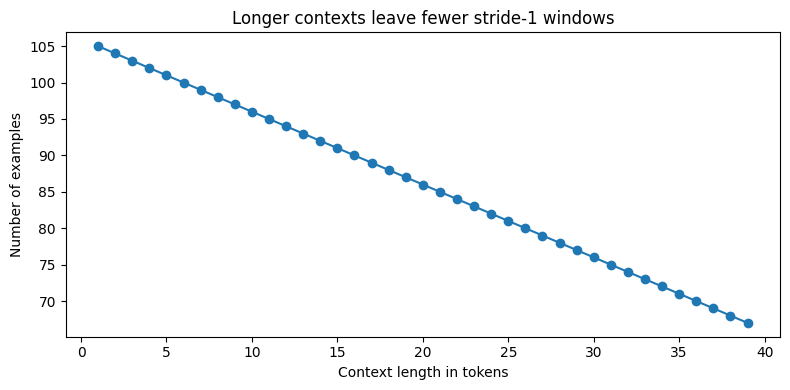

In [14]:
import matplotlib.pyplot as plt  # noqa: I001


possible_context_lengths = list(range(1, 40))
example_counts = [
    len(token_ids) - candidate_context_length
    for candidate_context_length in possible_context_lengths
]

plt.figure(figsize=(8, 4))
plt.plot(possible_context_lengths, example_counts, marker="o")
plt.xlabel("Context length in tokens")
plt.ylabel("Number of examples")
plt.title("Longer contexts leave fewer stride-1 windows")
plt.tight_layout()
plt.show()

## Understand the Resulting Shapes

The one-target inputs form a rectangular nested list with one row per example and one column per context position.

The targets contain one ID per row.

Later tensor notation will describe these shapes as `(number of examples, context length)` and `(number of examples,)`.

In [15]:
print(
    "Input shape:",
    (len(input_examples), len(input_examples[0])),
)
print("Target shape:", (len(target_examples),))

Input shape: (94, 12)
Target shape: (94,)


## Preview Shifted-Sequence Targets

One-target examples ask for one prediction after an entire context.

GPT-style training commonly asks for a next-token prediction at every position in an input sequence.

For `hello`, the input `hell` pairs with the target sequence `ello`.

In [16]:
input_sequence_ids = tiny_token_ids[:-1]
target_sequence_ids = tiny_token_ids[1:]

print(
    "Input text: ",
    repr(
        decode_character_ids(
            input_sequence_ids,
            tiny_id_to_character,
        )
    ),
)
print(
    "Target text:",
    repr(
        decode_character_ids(
            target_sequence_ids,
            tiny_id_to_character,
        )
    ),
)

Input text:  'hell'
Target text: 'ello'


Each target position is the token one step after the corresponding input position.

The relationship is still next-token prediction, but one window now supplies multiple targets.

## Build Fixed-Length Shifted Windows

For each start position, the target slice starts one token later than the input slice.

Both slices have the same length.

In [17]:
def build_shifted_sequence_examples(
    token_ids: list[int],
    sequence_length: int,
) -> tuple[list[list[int]], list[list[int]]]:
    if sequence_length < 1:
        raise ValueError("sequence_length must be at least 1 for this helper.")

    if sequence_length >= len(token_ids):
        raise ValueError(
            "sequence_length must leave one additional token for shifting."
        )

    input_sequences = []
    target_sequences = []

    for start_position in range(len(token_ids) - sequence_length):
        input_end = start_position + sequence_length
        input_sequences.append(token_ids[start_position:input_end])
        target_sequences.append(token_ids[start_position + 1 : input_end + 1])

    return input_sequences, target_sequences

In [18]:
sequence_length = 12
input_sequences, target_sequences = build_shifted_sequence_examples(
    token_ids,
    sequence_length,
)

assert len(input_sequences) == len(target_sequences)
assert all(len(sequence) == sequence_length for sequence in input_sequences)
assert all(len(sequence) == sequence_length for sequence in target_sequences)

for example_number in range(5):
    input_text = decode_character_ids(input_sequences[example_number], id_to_character)
    target_text = decode_character_ids(
        target_sequences[example_number], id_to_character
    )
    print(f"input={input_text!r}")
    print(f"target={target_text!r}")
    print()

input='The dog ran '
target='he dog ran a'

input='he dog ran a'
target='e dog ran ac'

input='e dog ran ac'
target=' dog ran acr'

input=' dog ran acr'
target='dog ran acro'

input='dog ran acro'
target='og ran acros'



## Compare the Two Formats

One-target format:

```text
input IDs shape:  (number of examples, context length)
target IDs shape: (number of examples,)
```

Shifted-sequence format:

```text
input IDs shape:  (number of examples, sequence length)
target IDs shape: (number of examples, sequence length)
```

Both formats require the same one-token shift, but they expose different numbers of supervised target positions per window.

## Reject Invalid Windows Clearly

The helper should explain when its requested window leaves no room for a target.

In [19]:
invalid_context_lengths = [0, len(token_ids)]

for invalid_context_length in invalid_context_lengths:
    try:
        build_next_token_examples(token_ids, invalid_context_length)
    except ValueError as error:
        print(f"context_length={invalid_context_length}: {error}")

context_length=0: context_length must be at least 1 for this helper.
context_length=106: context_length must leave at least one token for the target.


## Takeaways

- A fixed-context example contains previous token IDs and the ID immediately after them.
- With sequence length `N`, context length `C`, and stride 1, the number of examples is `N - C`.
- Decoded examples make target-shift and boundary mistakes visible.
- Spaces, punctuation, and newlines can all be targets when they are tokens.
- Longer contexts provide more history per example but fewer windows from fixed text.
- One-target examples have one target ID per context.
- Shifted-sequence examples have one next-token target at every sequence position.

The next chapter will use these examples with a uniform baseline model that assigns equal probability to every vocabulary token.